<a href="https://colab.research.google.com/github/TRACE-Structures/digital_twinning/blob/main/demo/notebooks/hybrid_toy_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Spring-Mass System with Hybrid Digital Twinning**  

This Jupyter Notebook demonstrates how to use a **Hybrid Digital Twinning** model with a simple **spring system** as a toy example. The model considers **mass (m)** and **stiffness (k)** as variable parameters to showcase the twinning process.  

### **System Overview**  
The spring-mass system follows Hooke’s Law and Newton’s Second Law:  

$$
F = -k x
$$

where:  
- \( k \) is the **spring stiffness**,  
- \( x \) is the **displacement from equilibrium**,  
- \( m \) is the **mass of the attached object**.  

### **Analytical Solution**  
For an ideal undamped system, the displacement at a given time step is given by:  

$$
u(T) = u_0 \cos \left( \sqrt{\frac{k}{m}} T \right) + \frac{v_0}{\sqrt{\frac{k}{m}}} \sin \left( \sqrt{\frac{k}{m}} T \right)
$$

where:  
- \( u_0 \) is the **initial displacement**,  
- \( v_0 \) is the **initial velocity**,  
- \( k \) and \( m \) can change dynamically in the twinning process,  
- **\( T = 10 \) is the single time step at which the system is evaluated**.  

### **Hybrid Digital Twinning Approach**  
- The model updates parameters (\( k, m \)) dynamically.  
- It integrates **physical equations** with **real-time data**.  
- Simulations showcase how the **digital twin adapts** to variations at a fixed moment in time (**T = 10**).  

### **Visualizations**  
This notebook includes:  
✅ **System state at \( T = 10 \) only** rather than a full time evolution.  
✅ **Phase-space representation** (velocity vs. displacement at \( T = 10 \)).  
✅ **3D plots** to visualize parameter influence at this specific time step.   


<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/TRACE-Structures/digital_twinning/main/demo/data/spring/spring.png" alt="Image" width="180">
</div>



# Imports

In [ ]:
! pip install digital_twinning

In [2]:
from uncertain_variables import *

import digital_twinning as dt
import pandas as pd

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Generate data

## Function to calculate

In [3]:
def spring_solve(q_i, x0=1, v0=0, d=0, T=10):
    # Solves the displacement of a damped spring-mass system at a given time step T.
    m = q_i[:,0]  # Mass values from input array
    k = q_i[:,1]  # Stiffness values from input array
    alpha = d / m  # Damping per unit mass
    D = (k / m) - (alpha ** 2)  # Adjusted natural frequency squared
    omega = np.sqrt(D)  # Damped angular frequency

    # Compute displacement at time T using the damped harmonic motion formula
    xt = np.exp(-alpha * T) * (x0 * np.cos(omega * T) + (v0 + alpha * x0) / omega * np.sin(omega * T))

    xt = xt.reshape(-1, 1)  # Ensure output is a column vector
    return xt

# Example usage:
x0, v0, d, T = 1, 0, 0, 10
spring_solve(np.array([[2, 2]]), x0, v0, d, T)

array([[-0.83907153]])

## Define Variables and VariableSet

In [4]:
# Define simulation parameters for mass (m) and stiffness (k),
# each following a uniform distribution within a given range.

P1 = Variable('m', UniformDistribution(0.5, 2.5))  # Mass (m) sampled from a uniform distribution between 0.5 and 2.5
P2 = Variable('k', UniformDistribution(0.5, 2.5))  # Stiffness (k) sampled from a uniform distribution between 0.5 and 2.5

# Create a set to store simulation parameters.
Q = VariableSet()

# Add the defined parameters (mass and stiffness) to the parameter set.
Q.add(P1)
Q.add(P2)


## Sampling

In [5]:
# Generate samples of simulation parameters (mass 'm' and stiffness 'k')
# We use the **Quasi-Monte Carlo (QMC)** sampling method with a **Halton sequence** for better convergence.
# The random seed ensures reproducibility of the sample set.
num_samples = 8000  # Define the number of samples to generate
Q_i = Q.sample(num_samples, method='QMC_Halton', random_seed=1997)  # Generate parameter samples
Q_df = pd.DataFrame(Q_i, columns=Q.variable_names())  # Convert the parameter samples into a DataFrame

# Generate target values (outputs) based on the parameter samples
# These are the quantities of interest (QoI), which represent the system's response (displacement) at a given time.
time_steps = 1  # In this case, we're only evaluating the system at a single time step (T=10)
QoI_i = spring_solve(Q_i)  # Solve the spring system for the generated parameter samples

# Define names for the QoI (displacement values) columns
# Since we're evaluating only a single time step (T=10), the output columns are named 't_1'
QoI_names = [f"t_{i+1}" for i in range(time_steps)]  # List comprehension for column naming

# Store the computed values of the quantities of interest (displacement at time T) in a DataFrame
QoI_df = pd.DataFrame(QoI_i, columns=QoI_names)  # Convert the results into a DataFrame


## 1 sample point

In [6]:
# Generate a single sample for the uncertain parameters (mass 'm' and stiffness 'k')
q_sample = Q.sample(1, random_seed=1)  # Sample a single set of parameters
qoi_sample = spring_solve(q_sample)  # Solve the spring system for the sampled parameters
q_sample_df = pd.DataFrame(q_sample, columns=Q.variable_names())  # Convert the sample to a DataFrame for easy viewing

# Plot response surface

In [7]:
# Define a grid of values for the spring stiffness (k) and mass (m)
# Both k and m are sampled between 0.5 and 2.5, with 200 points for each.
k_grid = np.linspace(0.5, 2.5, 200)  # Create a grid of stiffness values (k)
m_grid = np.linspace(0.5, 2.5, 200)  # Create a grid of mass values (m)

# Create a meshgrid to generate all combinations of k and m for evaluation
# This results in two 2D arrays (K and M) where K corresponds to stiffness and M to mass.
K, M = np.meshgrid(k_grid, m_grid)  # Generate a grid of parameter combinations

# Solve the spring system for each combination of mass and stiffness in the grid
# The spring_solve function is called with each (k, m) pair flattened into a single array.
Z_solver = spring_solve(np.array([[M.reshape(-1), K.reshape(-1)]]))  # Solve for each (m, k) pair
Z_solver = Z_solver.reshape(K.shape)  # Reshape the solution to match the grid shape for visualization


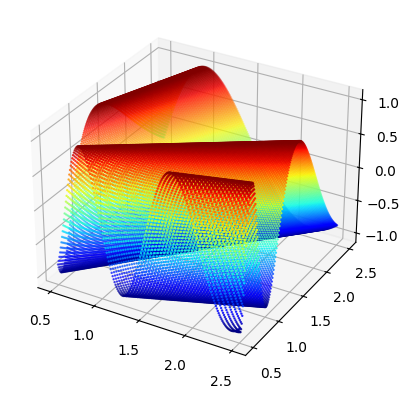

In [8]:
fig = dt.plot_3Dscatter(K, M, Z_solver)

# Model

## **Choosing the Model**

In this notebook, we implement the model using one of the following methods: **gPCE**, **DNN**, or **GBT**.

- **gPCE (Generalized Polynomial Chaos Expansion)**: Models uncertainty by expressing the output as a polynomial expansion, with coefficients determined by projecting the system's response onto orthogonal polynomials.

- **DNN (Deep Neural Networks)**: Machine learning models composed of interconnected neurons, capable of learning complex, non-linear patterns from data.

- **GBT (Gradient Boosting Trees)**: Combines weak decision trees into a strong predictive model, iteratively correcting errors from previous trees for robust performance.


In [9]:
method = "gPCE"

Set configurations

In [10]:
# Model configurations
match method:
    # DNN model configurations
    case "DNN":
        config = {
            'init_config' : {
                'layers': [
                    {'neurons': 512, 'activation': 'relu', 'dropout': 0.2},
                    {'neurons': 256, 'activation': 'sigmoid', 'dropout': 0.2},
                    {'neurons': 256, 'activation': 'sigmoid', 'dropout': 0.2},
                    {'neurons': 128, 'activation': 'relu', 'dropout': None},
                    ],
                'outputAF': 'tanh'
                },
            'train_config' : {
                'optimizer': 'Adam',
                'loss': 'MSE',
                'epochs': 100,
                'batch_size': 32,
                'k_fold': None,
                'early_stopping': {
                    'patience': 25,
                    'min_delta': 0.0001}
                }
                }
    # gPCE model configurations
    case "gPCE":
        config = {
            'init_config' : {
            'p' : 29
            },
            'train_config' : {
                'k_fold': 3
                }
        }
    # GBT model configurations
    case "GBT":
        config = {
            'init_config' : {
                'gbt_method': 'xgboost'
            },
            'train_config' : {
                'max_depth': 6,
                'num_of_iter': 250,
                'k_fold': 9
                }
        }

In [11]:
split_config = {
        'train_test_ratio': 0.8,
        'random_seed': 1997,
        'split_type': 'no_shuffle'
        }

## Define model

In [12]:
# Initialize surrogate model
# This creates an instance of the SurrogateModel class using the provided sampling data (Q),
model = dt.SurrogateModel(Q, QoI_names, method, **config['init_config'])
# Split data into training and testing sets
X_train, X_test, y_train, y_test = model.train_test_split(Q_df, QoI_df, **split_config)
# Train the model
model.train(X_train, y_train, **config['train_config'])

----- Training started for 'gPCE' model -----
Fold 1/3
Fold 2/3
Fold 3/3
Average train loss: 0.00000000000072, Average valid loss: 0.00000000000755
----- Training ended for 'gPCE' model -----


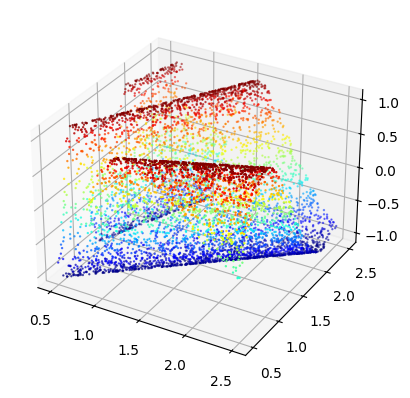

In [13]:
fig = dt.plot_3Dscatter(X_train['m'].to_numpy(), X_train['k'].to_numpy(), model.predict(X_train))

In [14]:
# get mean and variance of surrogate model
mean, var = model.get_mean_and_var()
mean, var

(array([-0.02419588]), array([0.50851146]))

## Calculate Sobol Sensitivities

In [15]:
# set max_index for Sobol sensitivity analysis
max_index = 2

partial_variance, sobol_index = model.get_sobol_sensitivity(max_index)

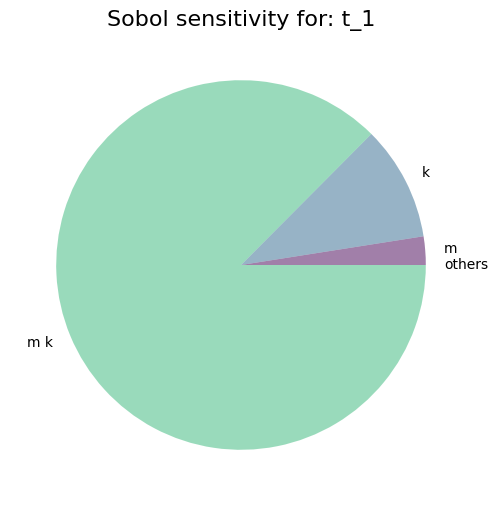

In [16]:
# Plot Sobol Sensitivity Index
# The 'plot_sobol_sensitivity' method generates a plot of Sobol Sensitivity indices, which quantify
# the contribution of each input parameter to the output uncertainty.
# - max_index: Specifies the maximum index of parameters to consider in the plot.
# - param_name: The name of the quantity of interest (QoI) for which sensitivity is being calculated ('t_1' in this case).
fig = model.plot_sobol_sensitivity(y_train, max_index=max_index, param_name='t_1')


## Calculate SHAP values

In [17]:
# Calculate SHAP (Shapley Additive Explanations) values
# The 'get_shap_values' method computes the SHAP values for the model's test data (model.X_test).
# SHAP values explain the contribution of each input feature to the prediction for each test sample.
# - model.X_test.iloc[:100]: The first 100 samples from the test set are selected for SHAP value computation.
# SHAP values help to interpret the model's decisions and understand the impact of each input parameter on the output.
shap_values = await model.get_shap_values(X_test, silent=True)


Message: sample size for shap values is set to 100.


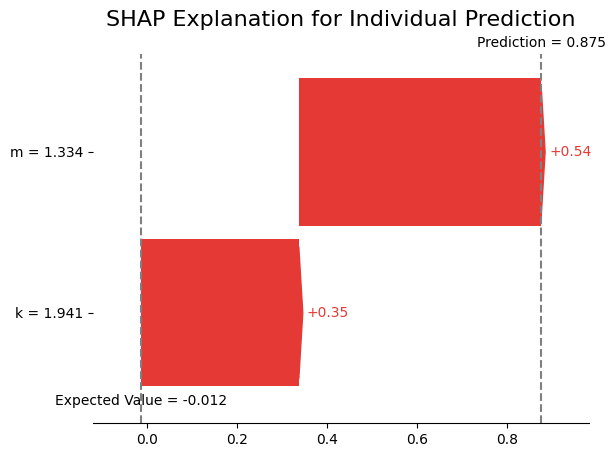

In [18]:
# Plot SHAP Single Waterfall Plot
# The 'plot_shap_single_waterfall' method generates a SHAP waterfall plot for a single test sample,
# visualizing how each feature contributes to the model's prediction for that sample.
# - q_sample_df: A DataFrame containing the sample data (e.g., a specific parameter set) for which the SHAP values are calculated.
# - param_name: The name of the quantity of interest (QoI) being analyzed ('t_1' in this case).
# The SHAP waterfall plot shows the cumulative effect of each feature on the model's prediction, helping to interpret individual predictions.
fig = await model.plot_shap_single_waterfall(X_test, silent=True, q=q_sample_df, param_name='t_1')

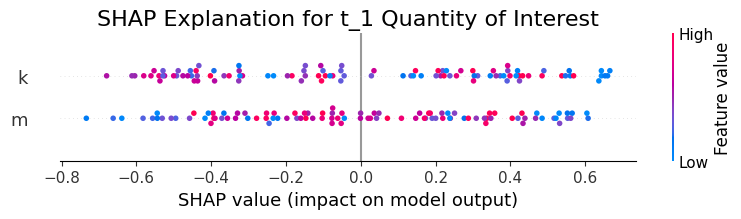

In [19]:
# Plot SHAP Beeswarm Plot
# The 'plot_shap_beeswarm' method generates a SHAP beeswarm plot, which visualizes the distribution of SHAP values
# for a range of test samples, showing the impact of each feature on the model’s predictions.
# - q: The test data (model.X_test.iloc[:100]) is selected for which SHAP values are calculated and visualized.
# - param_name: The name of the quantity of interest (QoI) for which SHAP values are computed ('t_1' in this case).
# The SHAP beeswarm plot shows how different input features influence the predictions across multiple samples,
# helping to understand the global feature importance and the relationships between features and the target.
fig = await model.plot_shap_beeswarm(X_test, silent=True, param_name='t_1')

In [20]:
# Make a prediction using the surrogate model
# - q_sample_df: A DataFrame containing the input parameter values for which the model will generate a prediction.
model.predict(q_sample_df)

array([[0.87506368]])

# Update

## Synthetic measurement

In [21]:
# Generate synthetic measurement data for the uncertain parameters (mass 'm' and stiffness 'k')
q_true = Q.sample(1, random_seed=3)  # Sample a single set of uncertain parameters, treated as synthetic measurement data
qoi_true = spring_solve(q_true)  # Solve the spring system for the synthetic parameters to get the true value of the quantity of interest
q_true_df = pd.DataFrame(q_true, columns=Q.variable_names())  # Convert the synthetic parameters to a DataFrame for easy viewing

# Define measurement error
s = 0.02  # Standard deviation of the measurement noise (2% error)
sigma = (np.ones(time_steps) * s).reshape(1, -1)  # Create an array of measurement noise values for each time step
sigma = pd.DataFrame(sigma, columns=QoI_names)  # Convert the noise values into a DataFrame
E = dt.generate_stdrn_simparamset(sigma.values.flatten())  # Generate the standard normal random variables for the noise
eps = E.sample(1)  # Sample a single set of random noise

# Synthetic measurement (measurement noise + true value)
qoi_m = qoi_true + eps  # Add the generated measurement noise to the true value to simulate a noisy measurement
qoi_m_df = pd.DataFrame(qoi_m, columns=QoI_names)  # Convert the noisy measurements to a DataFrame for easy viewing

print(q_true, qoi_true)

[[1.60159581 1.91629565]] [[-0.05711814]]


## Set parameters

In [22]:
# For Update
# The standard deviation of the error is computed using the statistics from the QoI DataFrame
sigma = QoI_df.describe().loc['std'] / 30  # Adjust standard deviation for each parameter in the QoI_df

# Generate the simulation parameter set (random noise) based on the updated measurement error (sigma)
E = generate_stndrn_variable_set(sigma.values.flatten())  # Generate random noise according to sigma values

# Set up the parameters for the Markov Chain Monte Carlo (MCMC) simulation
nwalkers = 64  # Number of walkers (parallel chains) in the MCMC process
nburn = 500  # Number of burn-in steps: these are discarded, as they help the MCMC chain reach equilibrium
niter = 100  # Total number of iterations for the MCMC process

In [23]:
# Initialize the Digital Twin model with the surrogate model and simulation parameter set (E)
DT = dt.DigitalTwin(model, E)  # Create a DigitalTwin instance that integrates the surrogate model and the random noise (E)

In [24]:
# Update the Digital Twin model with the synthetic measurement data and run MCMC sampling
DT.update(qoi_m_df, nwalkers=nwalkers, nburn=nburn, niter=niter)
# The 'update' method updates the Digital Twin using the synthetic measurement data (qoi_m_df)
# and performs MCMC sampling with the specified parameters (number of walkers, burn-in steps, and iterations)

MCMC creating
Burning period


100%|██████████| 500/500 [00:38<00:00, 13.15it/s]


MCMC running


100%|██████████| 100/100 [00:06<00:00, 14.43it/s]

--- 45.050318479537964 seconds ---


In [25]:
# Get the posterior mean and variance from the Digital Twin model
mean_of_post, variance_of_post = DT.get_mean_and_var_of_posterior()
# This returns the mean and variance of the posterior distribution after updating the model with data.

# Get the Maximum A Posteriori (MAP) estimate of the parameters
map = DT.get_MAP()
# This retrieves the most likely parameter values based on the updated model.

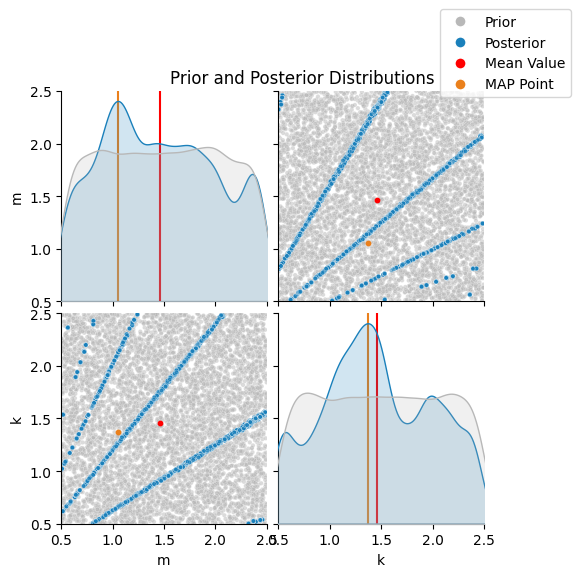

In [26]:
# Plot the MCMC sampling results along with the mean and MAP and true parameter values
fig = dt.plot_MCMC(model, X_train, DT, nwalkers=nwalkers, map_point=map)

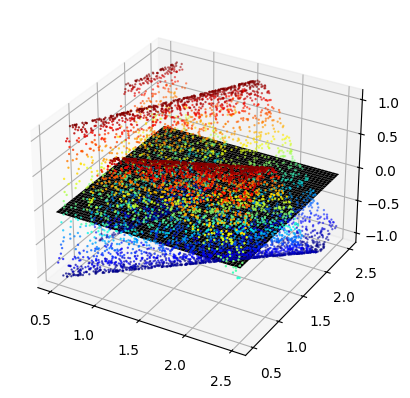

In [27]:
fig = dt.plot_3Dscatter(X_train['m'].to_numpy(), X_train['k'].to_numpy(), model.predict(X_train), K, M, qoi_true)

In [28]:
model.save_model('Spring_model', '')

Model saved to Spring_model.sm
